# Phase 2 — Model, Training, and Explainability
*Review 3 — Heart Sound Classification with XAI*

**Pipeline**
1. Environment setup (Drive mount / local path detection)
2. Data loading (uses Phase 1 outputs: `metadata.csv`, spectrograms, `split_indices.json`)
3. Model: ResNet50 + Squeeze-and-Excitation + Multi-Head Self-Attention
4. Two-phase training (frozen backbone → full fine-tune)
5. Test-set evaluation (accuracy, F1, AUC-ROC, AUC-PR, confusion matrix)
6. Explainability: Grad-CAM, attention maps, SHAP

**Run order**
- Run cells top-to-bottom in Colab (T4/L4) or locally with a CUDA GPU.
- Phase 1 must have been executed at least once so that `metadata.csv` and the cached `.npy` spectrograms exist.


## 0 — Mount Drive (Colab only) and install dependencies

In [1]:
# Colab: mount Drive. Skip silently on local.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not on Colab — skipping Drive mount.')

Mounted at /content/drive


In [2]:
# Install missing dependencies. Safe to re-run.
%pip install -q torch torchvision tqdm scikit-learn matplotlib seaborn pandas shap

## 1 — Imports and path detection

In [3]:
import sys
from pathlib import Path

# Make Review 3 modules importable when running from inside Colab / Jupyter
HERE = Path.cwd()
candidates = [
    HERE,
    HERE / 'Review 3',
    Path('/content/drive/MyDrive/CSE/College/RMS/Review 3'),
]
for c in candidates:
    if (c / 'config.py').exists():
        sys.path.insert(0, str(c))
        print(f'Loading modules from: {c}')
        break

from config   import (
    Paths, AudioConfig, ModelConfig, TrainConfig,
    CLASS_NAMES, get_device, set_seed, is_colab, is_drive_mounted,
)
from data     import load_metadata, load_class_weights, get_dataloaders, HeartSoundDataset
from model    import build_model
from train    import train, plot_training_history
from evaluate import evaluate_on_test, plot_confusion_matrix, plot_roc_pr_curves, save_predictions_csv
from xai      import visualise_gradcam, visualise_attention, compute_shap_values, plot_shap_frequency_importance, plot_shap_sample_overlays
from utils    import build_comparison_table, pick_explainable_indices, metrics_to_dict

Loading modules from: /content/drive/MyDrive/CSE/College/RMS/Review 3


In [4]:
# Path detection — change ``BASE_OVERRIDE`` if your Drive folder differs.
BASE_OVERRIDE = None  # e.g. '/content/drive/MyDrive/CSE/College/RMS'

paths     = Paths.auto_detect(base_override=BASE_OVERRIDE)
audio_cfg = AudioConfig()
model_cfg = ModelConfig()
train_cfg = TrainConfig()

paths.ensure_output_dirs()
set_seed(train_cfg.seed)
device = get_device()

print(f'Colab: {is_colab()}  |  Drive mounted: {is_drive_mounted()}  |  Device: {device}')
print(paths)

Colab: True  |  Drive mounted: True  |  Device: cuda
Paths:
  base_dir           = /content/drive/MyDrive/CSE/College/RMS
  data_dir           = /content/drive/MyDrive/CSE/College/RMS/physionet_2016  [OK]
  raw_dir            = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/raw  [OK]
  spec_dir           = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/spectrograms  [OK]
  metadata_csv       = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/metadata.csv  [OK]
  split_indices_json = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/split_indices.json  [OK]
  class_weights_pt   = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/class_weights.pt  [OK]
  output_dir         = /content/drive/MyDrive/CSE/College/RMS/Review 3/output  [OK]
  checkpoint_dir     = /content/drive/MyDrive/CSE/College/RMS/Review 3/output/checkpoints  [OK]


## 2 — Load data and inspect splits

In [5]:
df = load_metadata(paths)
print(f'Total recordings: {len(df)}')
print('Class distribution:', df['label'].value_counts().sort_index().to_dict())

train_loader, val_loader, test_loader, train_df, val_df, test_df = (
    get_dataloaders(paths, model_cfg, train_cfg, df)
)

class_weights = load_class_weights(paths, train_df, device=device)
print('Class weights:', class_weights.cpu().numpy())

Total recordings: 3541
Class distribution: {0: 2725, 1: 816}
  Loaded splits from split_indices.json
  Train: 2478 | Val:  531 | Test:  532
  Train class dist: {'Normal': 1907, 'Abnormal': 571}
  Val   class dist: {'Normal': 409, 'Abnormal': 122}
  Test  class dist: {'Normal': 409, 'Abnormal': 123}
Class weights: [0.23044337 0.76955664]


In [6]:
# Sanity-check a single batch
X_batch, y_batch = next(iter(train_loader))
print('Batch tensor shape :', tuple(X_batch.shape))
print('Value range        :', f'[{X_batch.min():.3f}, {X_batch.max():.3f}]')
print('First 8 labels     :', y_batch[:8].tolist())

Batch tensor shape : (32, 3, 224, 224)
Value range        : [-2.118, 2.637]
First 8 labels     : [1, 0, 0, 0, 0, 1, 1, 0]


## 3 — Build the model

In [7]:
model = build_model(model_cfg, device=device, pretrained=True, freeze_backbone=True)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


  Backbone frozen: True
  Trainable params: 18,363,906 / Total: 41,871,938


## 4 — Train

Set `NUM_EPOCHS` low for a smoke test, or keep the default 40 epochs for the full run.


[Phase A] Warm-up: backbone frozen, 10 epochs, lr=0.0003


  Train:   0%|          | 0/78 [00:00<?, ?it/s]

  Epoch 01/40 | loss 0.6599/0.8013 | acc 0.667/0.783 | f1 0.620


  Train:   0%|          | 0/78 [00:00<?, ?it/s]

  Epoch 02/40 | loss 0.5646/0.7038 | acc 0.732/0.759 | f1 0.649


...

  Epoch 28/40 | loss 0.2415/0.4731 | acc 0.965/0.908 | f1 0.861
  EarlyStopping: no improvement 6/8


  Train:   0%|          | 0/78 [00:00<?, ?it/s]

  Epoch 29/40 | loss 0.2311/0.3915 | acc 0.973/0.917 | f1 0.887
  EarlyStopping: no improvement 7/8


  Train:   0%|          | 0/78 [00:00<?, ?it/s]

  Epoch 30/40 | loss 0.2231/0.3860 | acc 0.975/0.913 | f1 0.880
  EarlyStopping: no improvement 8/8
  Early stop at epoch 30. Best epoch: 22

  Loaded best checkpoint (epoch 22, val_loss=0.3743) from /content/drive/MyDrive/CSE/College/RMS/Review 3/output/checkpoints/best_model.pth


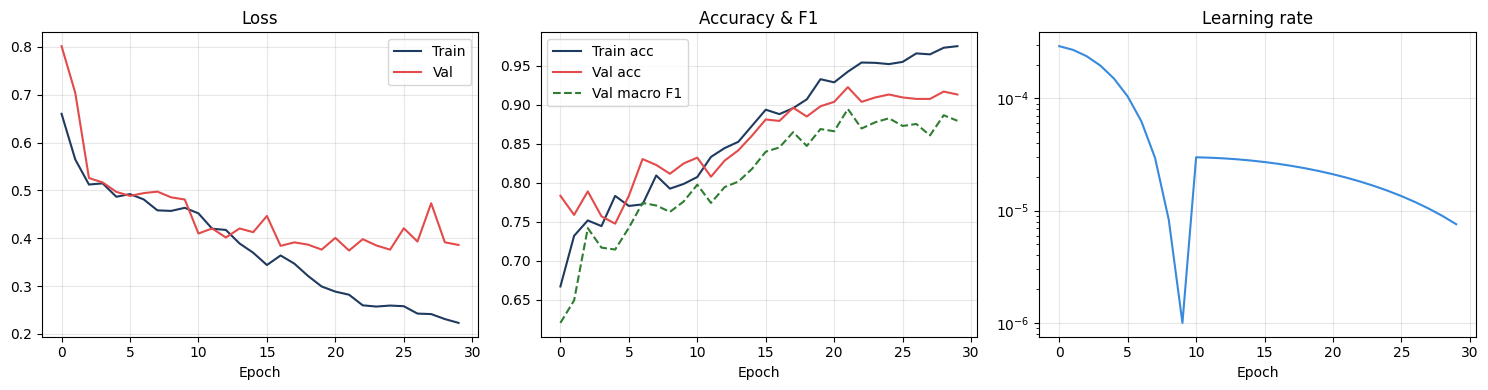

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/training_history.png


In [8]:
# Optional overrides for quick experimentation
# train_cfg.num_epochs    = 5
# train_cfg.warmup_epochs = 2
# train_cfg.batch_size    = 16

history = train(model, train_loader, val_loader, class_weights,
                paths, train_cfg, device)
plot_training_history(history, save_path=paths.output_dir / 'training_history.png')

## 5 — Evaluate on the held-out test set

  Test:   0%|          | 0/17 [00:00<?, ?it/s]


  Test set (532 samples) — 2 classes
  Accuracy          : 0.9079
  Balanced accuracy : 0.8861
  Macro precision   : 0.8642
  Macro recall      : 0.8861
  Macro F1          : 0.8743
  AUC-ROC           : 0.9457
  AUC-PR            : 0.8633
              precision    recall  f1-score   support

      Normal     0.9523    0.9267    0.9393       409
    Abnormal     0.7761    0.8455    0.8093       123

    accuracy                         0.9079       532
   macro avg     0.8642    0.8861    0.8743       532
weighted avg     0.9115    0.9079    0.9092       532



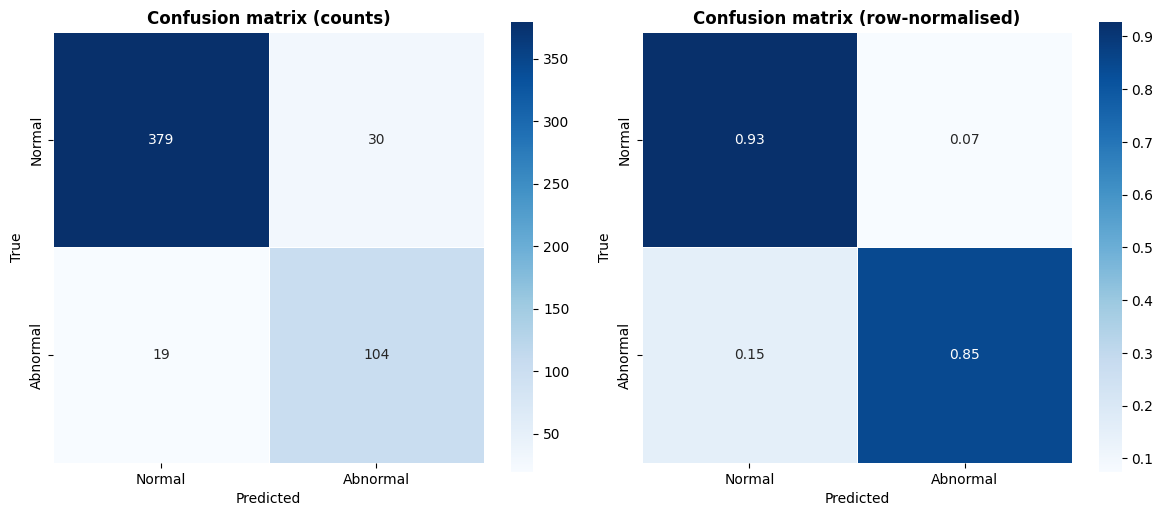

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/confusion_matrix.png


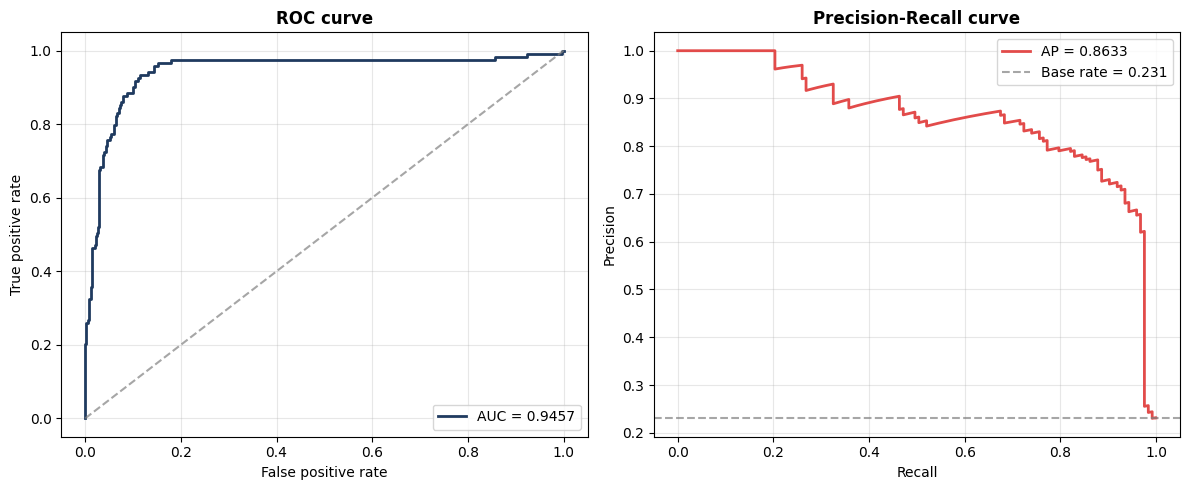

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/roc_pr_curves.png
  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/test_predictions.csv
Test metrics saved.


In [9]:
metrics = evaluate_on_test(model, test_loader, device, CLASS_NAMES)

plot_confusion_matrix(metrics, CLASS_NAMES,
                      save_path=paths.output_dir / 'confusion_matrix.png')
plot_roc_pr_curves(metrics, CLASS_NAMES,
                   save_path=paths.output_dir / 'roc_pr_curves.png')
save_predictions_csv(metrics, test_df, CLASS_NAMES,
                     save_path=paths.output_dir / 'test_predictions.csv')

import json
with open(paths.output_dir / 'test_metrics.json', 'w') as f:
    json.dump(metrics_to_dict(metrics), f, indent=2)
print('Test metrics saved.')

## 6 — Explainability

Grad-CAM + multi-head attention + SHAP, all overlaid on the original log-mel spectrogram so that time × frequency is directly readable.

In [10]:
test_dataset = HeartSoundDataset(test_df, paths, model_cfg, augment=False)
picks = pick_explainable_indices(metrics, n_correct=2, n_wrong=2,
                                 rng_seed=train_cfg.seed)
print('XAI sample indices:', picks)

XAI sample indices: [41, 344, 20, 356]


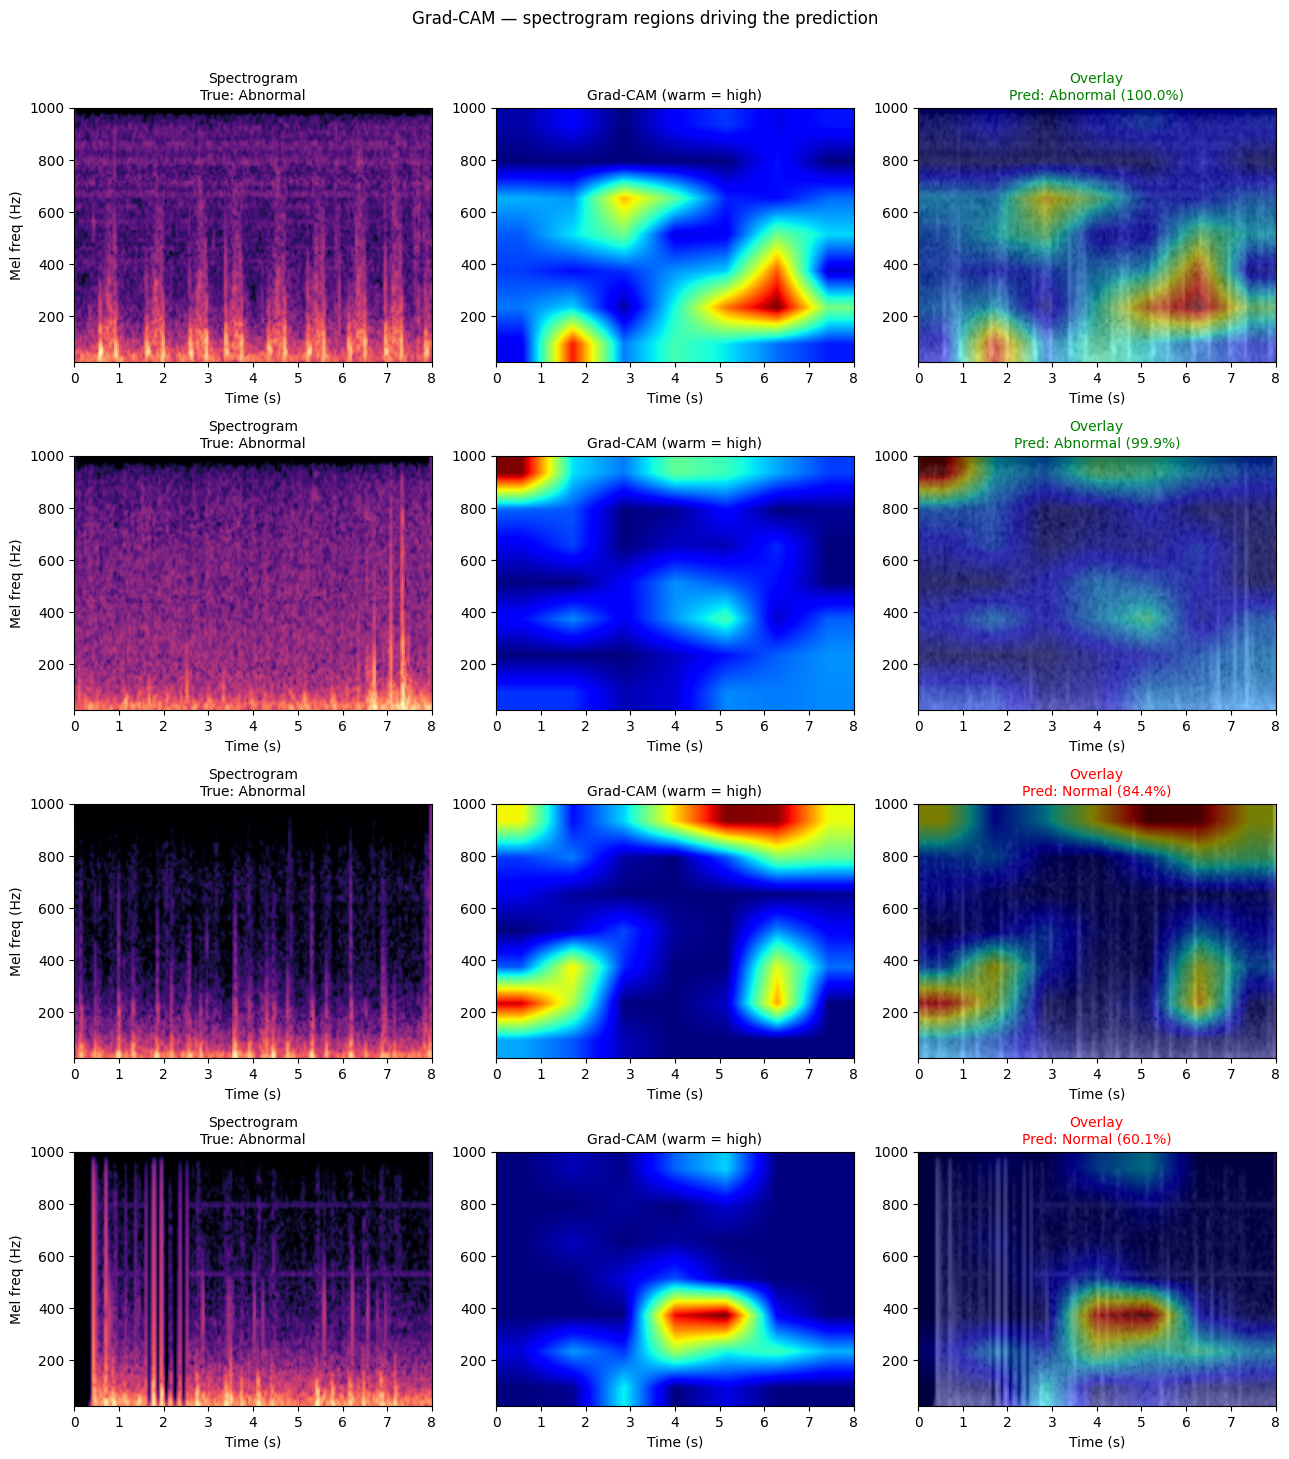

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/gradcam_overlays.png


In [11]:
# Grad-CAM — final ResNet50 conv layer
visualise_gradcam(model, test_dataset, picks, device, audio_cfg, CLASS_NAMES,
                  save_path=paths.output_dir / 'gradcam_overlays.png')

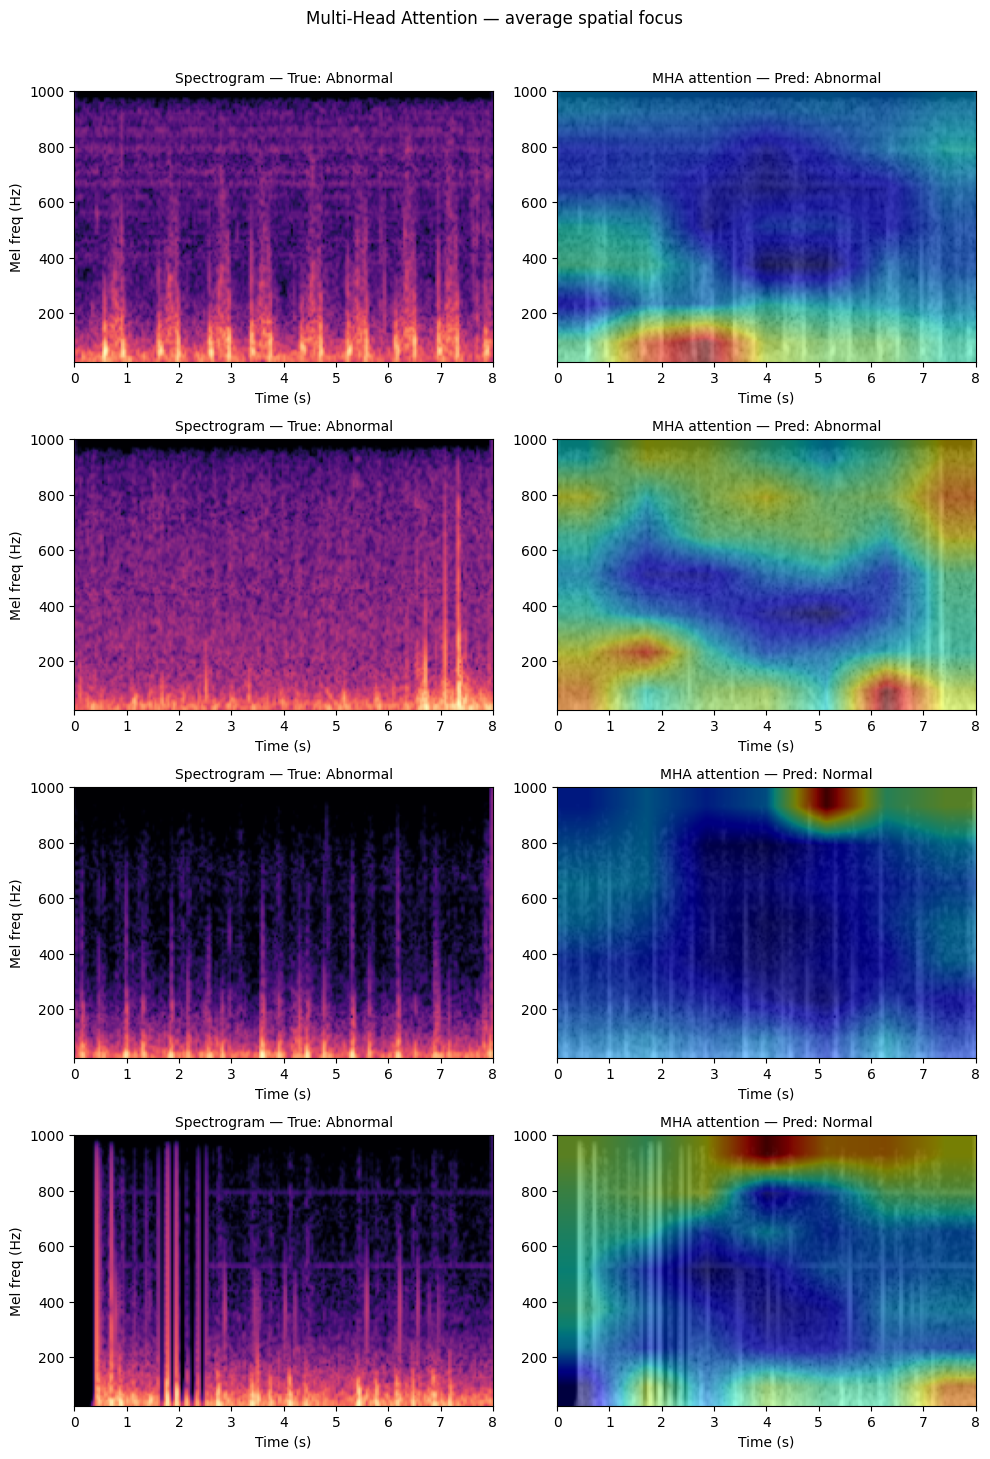

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/attention_overlays.png


In [12]:
# Multi-Head Attention — average over heads + queries
visualise_attention(model, test_dataset, picks, device, audio_cfg, CLASS_NAMES,
                    save_path=paths.output_dir / 'attention_overlays.png')

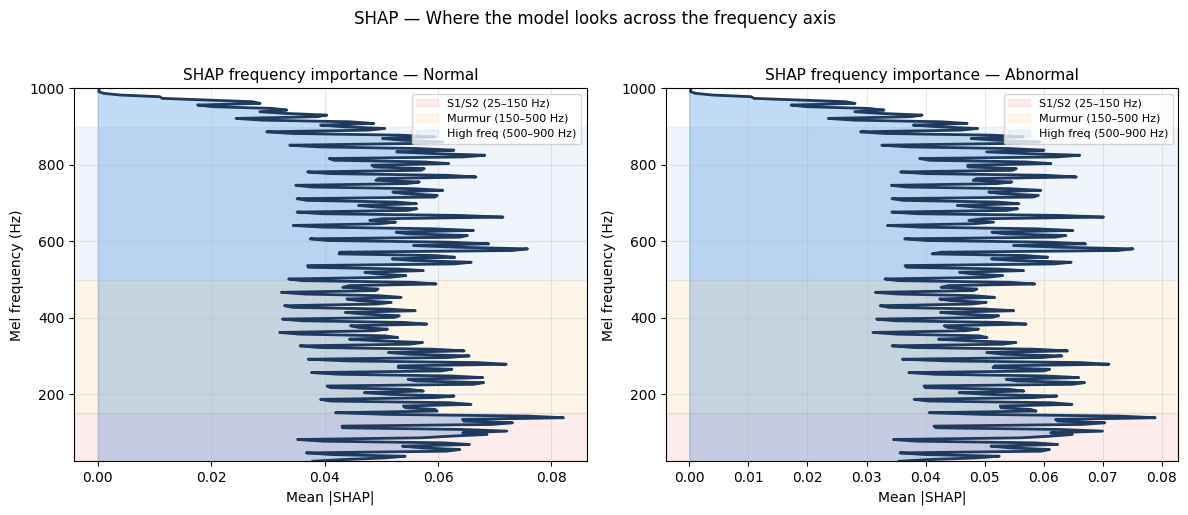

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/shap_frequency_importance.png


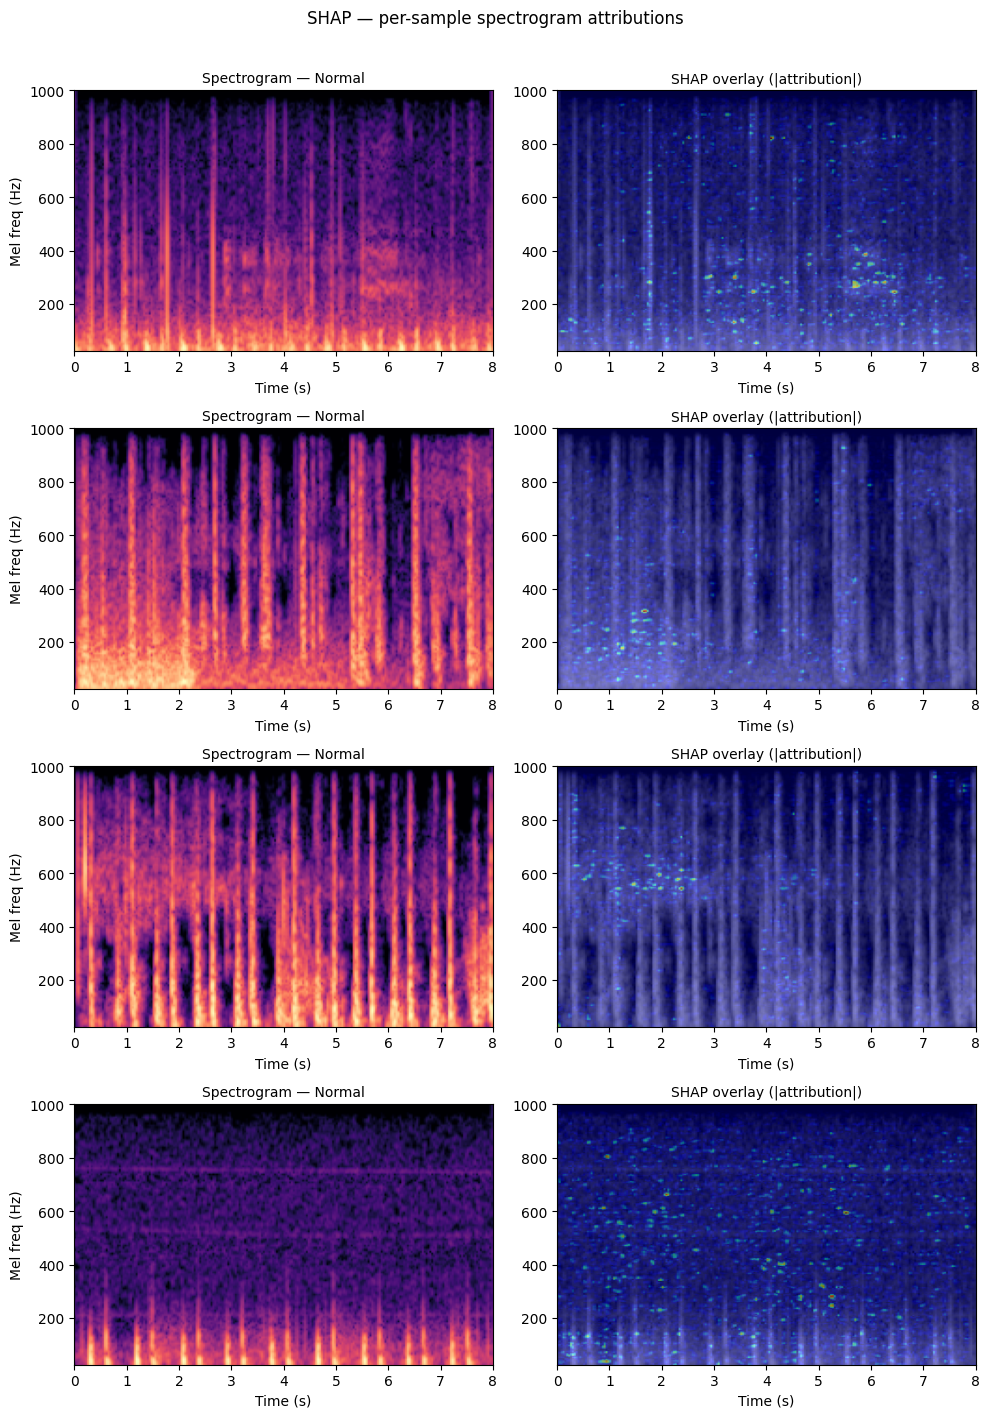

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/shap_sample_overlays.png


In [13]:
# SHAP — GradientExplainer (works with custom MHA head, unlike DeepExplainer)
shap_values, shap_inputs, shap_labels = compute_shap_values(
    model, train_loader, test_loader, device,
    n_background=32, n_explain=8,
)
plot_shap_frequency_importance(
    shap_values, audio_cfg, CLASS_NAMES,
    save_path=paths.output_dir / 'shap_frequency_importance.png')
plot_shap_sample_overlays(
    shap_values, shap_inputs, shap_labels, audio_cfg, CLASS_NAMES,
    save_path=paths.output_dir / 'shap_sample_overlays.png')

## 7 — Comparison table for the report

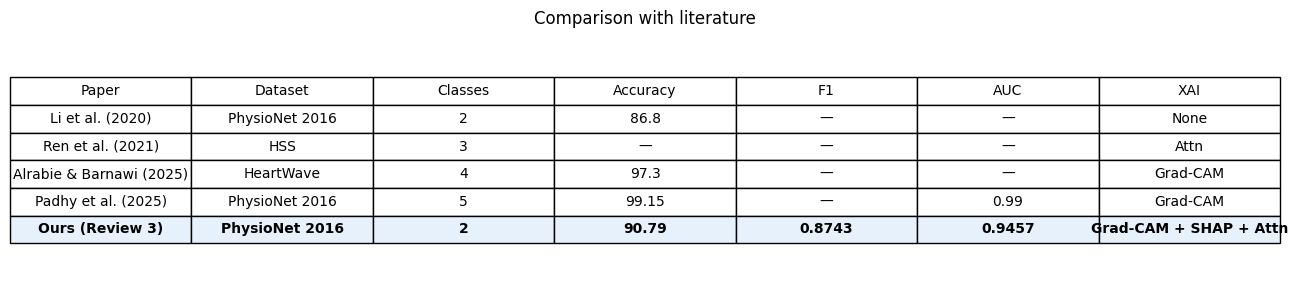

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/comparison_table.png


,Paper,Dataset,Classes,Accuracy,F1,AUC,XAI
0,Li et al. (2020),PhysioNet 2016,2,86.8,—,—,None
1,Ren et al. (2021),HSS,3,—,—,—,Attn
2,Alrabie & Barnawi (2025),HeartWave,4,97.3,—,—,Grad-CAM
3,Padhy et al. (2025),PhysioNet 2016,5,99.15,—,0.99,Grad-CAM
4,Ours (Review 3),PhysioNet 2016,2,90.79,0.8743,0.9457,Grad-CAM + SHAP + Attn


In [14]:
build_comparison_table(metrics,
                       save_path=paths.output_dir / 'comparison_table.png')

## Summary

Artifacts produced in `paths.output_dir`:
- `training_history.png` — loss / accuracy / F1 / LR curves
- `confusion_matrix.png` — counts + row-normalised
- `roc_pr_curves.png`    — ROC and PR curves
- `test_predictions.csv` — per-recording probabilities and predictions
- `test_metrics.json`    — scalar metrics
- `gradcam_overlays.png`, `attention_overlays.png`, `shap_*.png` — XAI plots
- `comparison_table.png` — versus literature
- `checkpoints/best_model.pth` + `history.json` — model + training trace
